In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [4]:
data = pd.read_csv(r'C:\Users\Mayur23\OneDrive\Desktop\pareet\Student Feedback Analysis System\data\feedback_cleaned.csv')
data['Open_feedback'] = data['Open_feedback'].fillna('')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Respondent_id          2000 non-null   object 
 1   Program                2000 non-null   object 
 2   Batch                  2000 non-null   object 
 3   Institution            2000 non-null   object 
 4   Delivery_mode          2000 non-null   object 
 5   Gender                 2000 non-null   object 
 6   Academic_year          2000 non-null   object 
 7   Trainer_effectiveness  2000 non-null   float64
 8   Curriculum_relevance   2000 non-null   float64
 9   Pace_of_delivery       2000 non-null   float64
 10  Support_Mentorship     2000 non-null   float64
 11  Platform               2000 non-null   float64
 12  Overall_satisfaction   2000 non-null   int64  
 13  Would_recommend        2000 non-null   object 
 14  Open_feedback          2000 non-null   object 
 15  Batc

LOGISTIC REGRESSION

In [7]:
data['Overall_satisfaction'].value_counts()

Overall_satisfaction
4    911
3    571
5    410
2    107
1      1
Name: count, dtype: int64

In [8]:
data['Low_satisfaction'] = (data['Overall_satisfaction'] <= 3).astype(int)

In [ ]:
features = ['Trainer_effectiveness','Curriculum_relevance','Pace_of_delivery','Support_Mentorship','Platform']
x = data[features]
y = data['Low_satisfaction']

x_train , x_test , y_train , y_test = train_test_split(x , y , random_state = 42 , stratify = y)


In [15]:
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [18]:
y_pred = model.predict(x_test)

In [21]:
print("Accuracy score = ",accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

Accuracy score =  0.886
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       319
           1       0.86      0.81      0.84       181

    accuracy                           0.89       500
   macro avg       0.88      0.87      0.87       500
weighted avg       0.89      0.89      0.89       500



In [22]:
coefficients = pd.Series(model.coef_[0], index=features).sort_values()
print(coefficients)

Trainer_effectiveness   -2.353222
Support_Mentorship      -1.534326
Pace_of_delivery        -1.240534
Platform                -1.229807
Curriculum_relevance    -1.209480
dtype: float64


K-MEANS CLUSTERING

In [26]:
x_cluster = data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_cluster)

In [28]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(X_scaled)

In [30]:
data.groupby('Cluster')[features].mean()

,Trainer_effectiveness,Curriculum_relevance,Pace_of_delivery,Support_Mentorship,Platform
Cluster,,,,,
0,2.651639,2.610656,2.221311,2.745902,2.282787
1,4.159463,4.078987,3.639344,4.196721,3.642325
2,4.808712,4.734848,4.467803,4.808712,4.517045
3,3.461400,3.369838,3.059246,3.488330,3.093357


In [31]:
data['Cluster'].value_counts()

Cluster
1    671
3    557
2    528
0    244
Name: count, dtype: int64

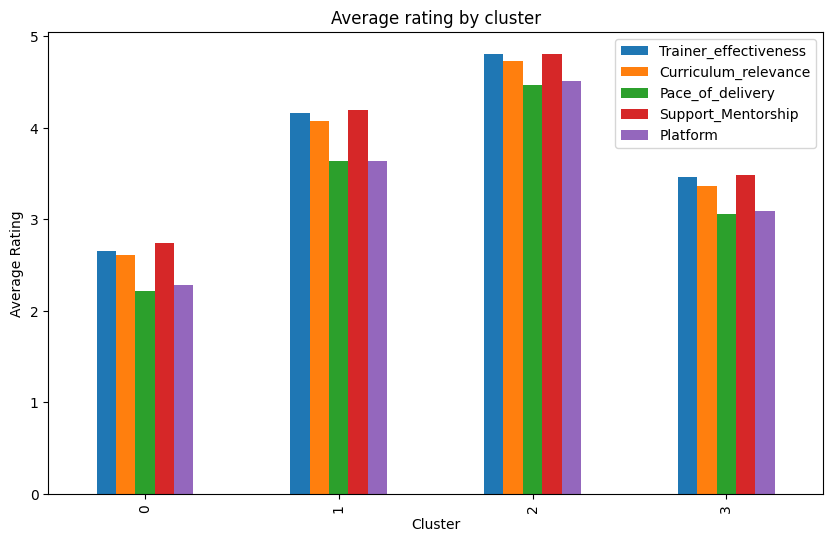

In [39]:
data.groupby('Cluster')[features].mean().plot(kind = 'bar',figsize = (10,6))
plt.title('Average rating by cluster')
plt.ylabel('Average Rating')
plt.savefig(r'C:\Users\Mayur23\OneDrive\Desktop\pareet\Student Feedback Analysis System\notebooks\outputs')
plt.show()

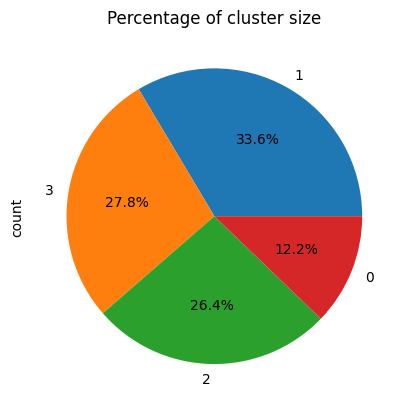

In [45]:
data['Cluster'].value_counts().plot(kind = 'pie',autopct = '%1.1f%%')
plt.title('Percentage of cluster size')
plt.savefig(r'C:\Users\Mayur23\OneDrive\Desktop\pareet\Student Feedback Analysis System\notebooks\outputs')
plt.show()